In [1]:
%load_ext autoreload
%autoreload 2
import sys
import os

# project_path = "/root/25DFT/QHFlow/src/common"
# sys.path.append(project_path)
sys.path.append("/root/limlab01/kaistai/25DFT/QHFlow/src")
# from common.dft_utils import *
from dft_process.dft_process_utils import *
from common.draw_util import *

INFO     [dft_process_utils.py:32] >> Source path: /root/limlab01/kaistai/25DFT/QHFlow/src

INFO     [dft_process_utils.py:62] >> Root path: /root/limlab01/kaistai/25DFT/QHFlow

In [2]:
from matplotlib import colormaps
list(colormaps)

['magma',
 'inferno',
 'plasma',
 'viridis',
 'cividis',
 'twilight',
 'twilight_shifted',
 'turbo',
 'berlin',
 'managua',
 'vanimo',
 'Blues',
 'BrBG',
 'BuGn',
 'BuPu',
 'CMRmap',
 'GnBu',
 'Greens',
 'Greys',
 'OrRd',
 'Oranges',
 'PRGn',
 'PiYG',
 'PuBu',
 'PuBuGn',
 'PuOr',
 'PuRd',
 'Purples',
 'RdBu',
 'RdGy',
 'RdPu',
 'RdYlBu',
 'RdYlGn',
 'Reds',
 'Spectral',
 'Wistia',
 'YlGn',
 'YlGnBu',
 'YlOrBr',
 'YlOrRd',
 'afmhot',
 'autumn',
 'binary',
 'bone',
 'brg',
 'bwr',
 'cool',
 'coolwarm',
 'copper',
 'cubehelix',
 'flag',
 'gist_earth',
 'gist_gray',
 'gist_heat',
 'gist_ncar',
 'gist_rainbow',
 'gist_stern',
 'gist_yarg',
 'gnuplot',
 'gnuplot2',
 'gray',
 'hot',
 'hsv',
 'jet',
 'nipy_spectral',
 'ocean',
 'pink',
 'prism',
 'rainbow',
 'seismic',
 'spring',
 'summer',
 'terrain',
 'winter',
 'Accent',
 'Dark2',
 'Paired',
 'Pastel1',
 'Pastel2',
 'Set1',
 'Set2',
 'Set3',
 'tab10',
 'tab20',
 'tab20b',
 'tab20c',
 'grey',
 'gist_grey',
 'gist_yerg',
 'Grays',
 'magma_r',

In [3]:
md17_experiment = MD17Experiment(data_index=0)
md17_experiment.set_model_path()

INFO     [setup.py:66] >> Seed: 0

Seed set to 0


INFO     [dft_process_utils.py:192] >> [!] conf.dataset.dataset_name: water

In [4]:
dataset = md17_experiment.dataset

print("dataset[0]: ", dataset[0])
print_data_item(dataset[0])

dataset[0]:  AOData(pos=[3, 3], atoms=[3, 1], energy=[1], force=[3, 3], AO_index=[3, 24], hamiltonian=[1, 24, 24], init_ham=[1, 24, 24], overlap=[1, 24, 24], num_atoms=[1], AO_l_index=[12], AO_l_index_len=[1, 1], full_edge_index=[2, 6], mask_row=[3, 14], Q=[24, 24, 60])
data:  AOData(pos=[3, 3], atoms=[3, 1], energy=[1], force=[3, 3], AO_index=[3, 24], hamiltonian=[1, 24, 24], init_ham=[1, 24, 24], overlap=[1, 24, 24], num_atoms=[1], AO_l_index=[12], AO_l_index_len=[1, 1], full_edge_index=[2, 6], mask_row=[3, 14], Q=[24, 24, 60])
 0: hamiltonian    , torch.Size([1, 24, 24])
 1: num_atoms      , torch.Size([1])
 2: full_edge_index, torch.Size([2, 6])
 3: overlap        , torch.Size([1, 24, 24])
 4: init_ham       , torch.Size([1, 24, 24])
 5: force          , torch.Size([3, 3])
 6: pos            , torch.Size([3, 3])
 7: mask_row       , torch.Size([3, 14])
 8: energy         , torch.Size([1])
 9: Q              , torch.Size([24, 24, 60])
10: AO_l_index     , torch.Size([12])
11: atoms 

In [5]:
pred_list = md17_experiment.pred_list()
print_first_item(pred_list)
gt_list = md17_experiment.gt_list()
print_first_item(gt_list)
print()

len(pred): 3999, water
First item keys: dict_keys(['pred_hamiltonian', 'overlap', 'pos', 'atoms', 'format', 'length_unit'])
len(gt): 3999, water
First item keys: dict_keys(['hamiltonian', 'overlap', 'pos', 'atoms', 'format', 'length_unit', 'init_ham', 'energy', 'force', 'calc_energy', 'calc_forces'])



In [6]:
def matshow(matrix, max_val=None, max_mul=0.1, colorbar=True, frame=True, ticks=False, save_name=None, drawline=[], cmap='bwr', colored_norm=False, log=False):
    fig, ax = plt.subplots()
    if matrix.ndim == 3:
        matrix = matrix[0]
    if max_val is None:
        max_val = matrix.abs().max() * max_mul
    cur_matrix = matrix
    if log:
        # Add small constant to avoid log(0)
        eps = 1e-10
        cur_matrix = torch.sign(matrix) * torch.log(torch.abs(matrix) + eps)

    if colored_norm:
        # Use matrix values directly for coloring without normalization
        im = ax.imshow(cur_matrix, cmap=cmap)
    else:
        # Normalize to symmetric range around 0
        im = ax.imshow(cur_matrix, cmap=cmap, vmin=-max_val, vmax=max_val)
        
    if colorbar:
        fig.colorbar(im)
    if not ticks:
        ax.set_xticks([])
        ax.set_yticks([])
    
    spines_name = ['top', 'right', 'bottom', 'left']
    for spine in spines_name:
        ax.spines[spine].set_color('black')
        ax.spines[spine].set_linewidth(0.5)
    
    if not frame: 
        for spine in spines_name:
            ax.spines[spine].set_visible(False)
    
    cur = 0
    for idx, orb_num in enumerate(drawline):
        color = 'gray'
        ls = '--'
        lw = 0.3
        if orb_num < 0:
            orb_num = -orb_num
            color = 'black'
            ls = '-'
            lw = 0.5
        cur = cur + orb_num
        ax.axhline(y=cur-0.5, color=color, linestyle=ls, linewidth=lw)
        ax.axvline(x=cur-0.5, color=color, linestyle=ls, linewidth=lw)
    if save_name is not None:
        plt.savefig(save_name, bbox_inches='tight', dpi=600)
    plt.show()
    
    max_val = matrix.abs().max()
    min_val = matrix.abs().min()
    mean_val = matrix.mean()
    std_val = matrix.std()
    abs_mean_val = matrix.abs().mean()
    abs_std_val = matrix.abs().std()
    statistics = {
        "max_val": max_val,
        "min_val": min_val,
        "abs_mean_val": abs_mean_val,
        "abs_std_val": abs_std_val,
        "mean_val": mean_val,
        "std_val": std_val,
    }
    return statistics

In [7]:
import models.layers_v2 as layers_v2
import e3nn.o3 as o3

In [8]:
expand = layers_v2.PureExpansion(
    o3.Irreps("3x0e + 2x1e + 1x2e"),
    o3.Irreps("3x0e + 2x1e + 1x2e"),
    o3.Irreps("3x0e + 2x1e + 1x2e"),
)

In [9]:
# 1s, 2s, 2p, 3s, 3p, 4s, 3d
index = [
         0, # 1s O
         1, # 2s 
         2, # 3s 
         3,4,5, # 2p
         6,7,8, # 3p
         9,10,11,12,13, # 3d
         14, # 1s
         15, # 2s
         16,17,18, # 2p
         19, # 1s
         20, # 2s
         21,22,23 # 2p    
       ]

drawline=[1,1,1,3,3,-5,1,1,-3,1,1,-3]

In [10]:
batch = dataset[0]
batch.ptr = torch.tensor([0, batch.num_nodes])

In [11]:
from common.matrix_transforms import _build_final_matrix, _get_orbital_mask

In [12]:
random_diag_tensor = o3.Irreps("3x0e + 2x1e + 1x2e").randn(
    batch.atoms.shape[0], -1
)
random_non_diag_tensor = o3.Irreps("3x0e + 2x1e + 1x2e").randn(
    batch.full_edge_index.shape[1], -1
)
random_diag_ham = expand(random_diag_tensor)
random_non_diag_ham = expand(random_non_diag_tensor)
random_ham = _build_final_matrix(
 
    batch, random_diag_ham, random_non_diag_ham, _get_orbital_mask()
)
random_ham = torch.stack(random_ham, dim=0) * 1.0

In [13]:
def sym_random(matrix):
    m_dim = matrix.shape[-1]
    i,j = torch.triu_indices(m_dim, m_dim)
    rand_matrix = torch.randn_like(matrix)
    if matrix.ndim == 3:
        rand_matrix[:, i, j] = rand_matrix[:, j, i]
    else:
        rand_matrix[i, j] = rand_matrix[j, i]
    return rand_matrix

In [14]:
GOE0 = sym_random(batch.hamiltonian) * 0.5
Expd0 = (random_ham + random_ham.transpose(-1,-2)) / 2.0
Target0 = batch.hamiltonian

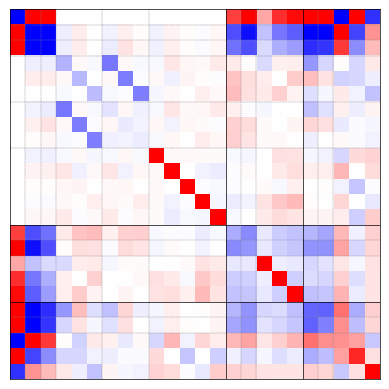

{'max_val': tensor(18.9796),
 'min_val': tensor(4.0913e-07),
 'abs_mean_val': tensor(0.2864),
 'abs_std_val': tensor(0.9767),
 'mean_val': tensor(0.0008),
 'std_val': tensor(1.0179)}

In [28]:
init_ham = batch.init_ham
matshow(init_ham,drawline=[1,1,1,3,3,-5,1,1,-3,1,1,-3], cmap='bwr', colorbar=False,max_val=1.0)

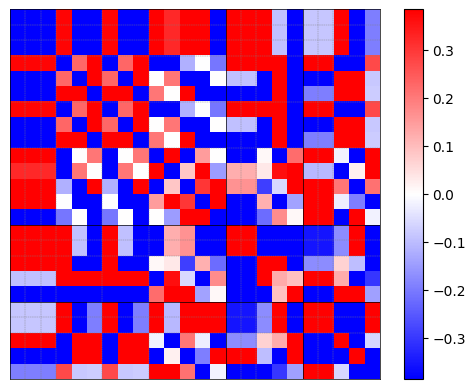

{'max_val': tensor(3.8531),
 'min_val': tensor(0.),
 'abs_mean_val': tensor(0.8272),
 'abs_std_val': tensor(0.7932),
 'mean_val': tensor(-0.2445),
 'std_val': tensor(1.1201)}

In [ ]:
matshow(Expd0,drawline=[1,1,1,3,3,-5,1,1,-3,1,1,-3])

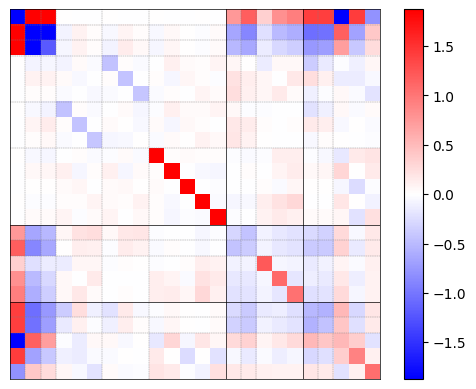

{'max_val': tensor(18.7209),
 'min_val': tensor(0.0001),
 'abs_mean_val': tensor(0.2773),
 'abs_std_val': tensor(0.9648),
 'mean_val': tensor(0.0099),
 'std_val': tensor(1.0038)}

In [16]:
matshow(Target0,drawline=[1,1,1,3,3,-5,1,1,-3,1,1,-3])

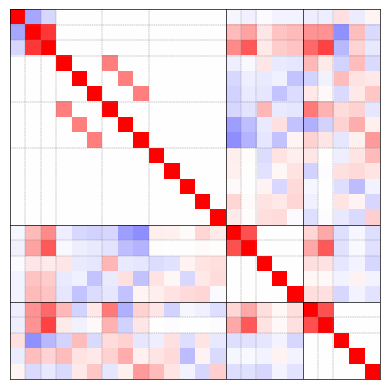

{'max_val': tensor(1.),
 'min_val': tensor(0.),
 'abs_mean_val': tensor(0.1421),
 'abs_std_val': tensor(0.2302),
 'mean_val': tensor(0.0707),
 'std_val': tensor(0.2612)}

In [27]:
overlap = batch.overlap.squeeze()
matshow(overlap,drawline=[1,1,1,3,3,-5,1,1,-3,1,1,-3], cmap='bwr', colorbar=False,max_val=1.0)

{'max_val': tensor(6.8529),
 'min_val': tensor(-18.7209),
 'abs_mean_val': tensor(0.2773),
 'abs_std_val': tensor(0.9648),
 'mean_val': tensor(0.0099),
 'std_val': tensor(1.0038)}

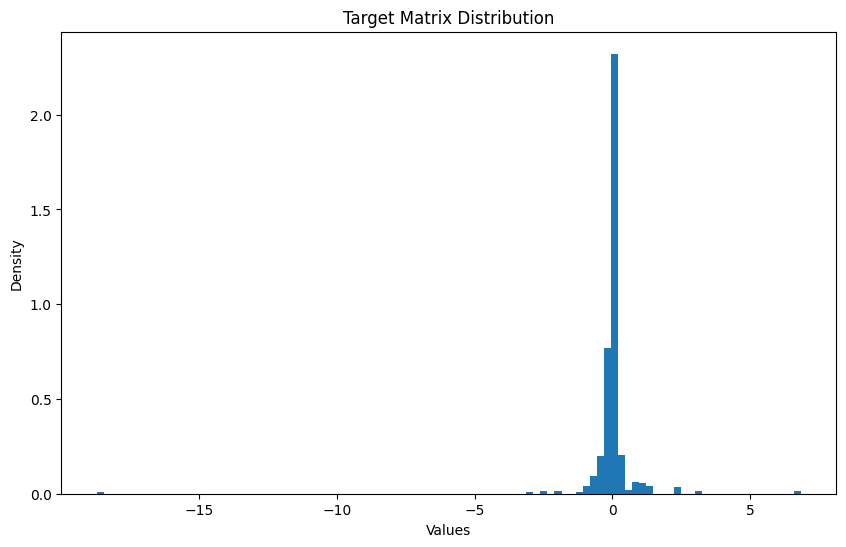

In [17]:
def plot_matrix_distribution(matrix, title="Matrix Distribution", abs_only=False, log_scale=False):
    """Plot the distribution of values in a matrix.
    
    Args:
        matrix (torch.Tensor): Input matrix to analyze
        title (str): Title for the plot
    
    Returns:
        dict: Statistics of the matrix distribution
    """
    # Flatten the matrix and convert to numpy for plotting
    flat_values = matrix.flatten().detach().numpy()
    if abs_only:
        flat_values = np.abs(flat_values)
    
    plt.figure(figsize=(10, 6))
    plt.hist(flat_values, bins=100, density=True)
    plt.title(title)
    plt.xlabel("Values")
    plt.ylabel("Density")
    if log_scale:
        plt.xscale('log')
        
    # Calculate statistics
    stats = {
        'max_val': matrix.max(),
        'min_val': matrix.min(),
        'abs_mean_val': matrix.abs().mean(),
        'abs_std_val': matrix.abs().std(),
        'mean_val': matrix.mean(),
        'std_val': matrix.std()
    }
    
    return stats

# Plot distribution for Target0
target_stats = plot_matrix_distribution(Target0, "Target Matrix Distribution")
target_stats


In [18]:
init_ham_list = []
for i in range(len(batch.atoms)):
    pos = batch.pos[i].unsqueeze(0)
    atoms = batch.atoms[i].unsqueeze(0)
    
    # Calculate total number of electrons for spin
    total_electrons = sum([a.item() for a in atoms])
    spin = 1 if total_electrons % 2 else 0
    
    mol = gto.Mole()
    mol_conf = [[atoms[atom_idx], pos[atom_idx]] for atom_idx in range(len(atoms))]
    mol.build(verbose=0, atom=mol_conf, basis="def2-svp", unit="bohr", spin=spin)
    
    mf = dft.RKS(mol)
    mf.xc = 'pbe'
    init_dm = mf.get_init_guess(key='minao') 
    init_ham = mf.get_fock(dm=init_dm)
    
    init_ham_list.append(init_ham)

In [19]:
mid_mask = [
    np.arange(14),
    np.arange(5),
    np.arange(5),
] # water

diag_ham_init = torch.zeros_like(batch.init_ham).squeeze()
diag_mask = torch.zeros_like(batch.init_ham).squeeze()
cnt = 0
for i in range(len(mid_mask)):
    orb_len = len(mid_mask[i])
    cur_mask = orb_len + cnt
    diag_ham_init[cnt:cur_mask, cnt:cur_mask] = torch.from_numpy(init_ham_list[i])
    diag_mask[cnt:cur_mask, cnt:cur_mask] = torch.ones(orb_len,orb_len)
    cnt = cur_mask

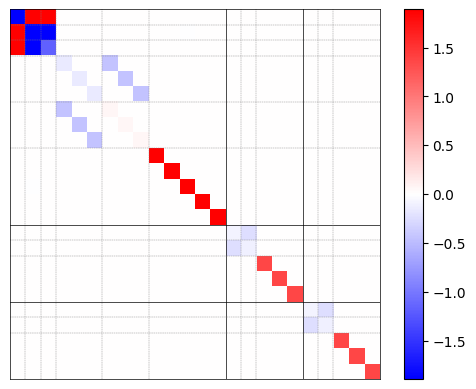

{'max_val': tensor(18.9063),
 'min_val': tensor(0.),
 'abs_mean_val': tensor(0.1259),
 'abs_std_val': tensor(0.9570),
 'mean_val': tensor(0.0162),
 'std_val': tensor(0.9652)}

In [20]:
matshow(diag_ham_init,drawline=[1,1,1,3,3,-5,1,1,-3,1,1,-3])

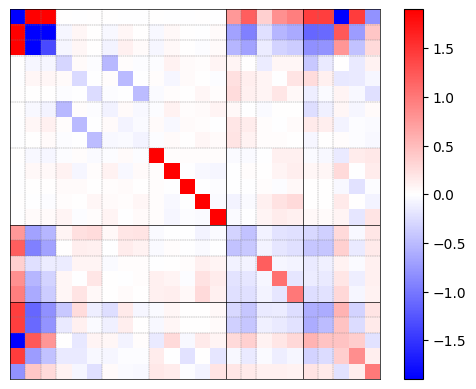

{'max_val': tensor(18.9796),
 'min_val': tensor(4.0913e-07),
 'abs_mean_val': tensor(0.2864),
 'abs_std_val': tensor(0.9767),
 'mean_val': tensor(0.0008),
 'std_val': tensor(1.0179)}

In [21]:
Init_H = batch.init_ham
matshow(Init_H,drawline=[1,1,1,3,3,-5,1,1,-3,1,1,-3])

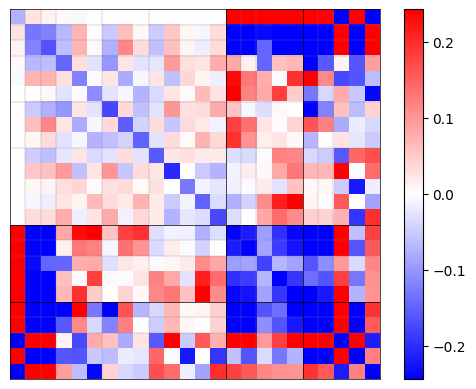

{'max_val': tensor(2.4301),
 'min_val': tensor(4.0913e-07),
 'abs_mean_val': tensor(0.1734),
 'abs_std_val': tensor(0.2856),
 'mean_val': tensor(-0.0155),
 'std_val': tensor(0.3339)}

In [22]:
matshow(Init_H-diag_ham_init,drawline=[1,1,1,3,3,-5,1,1,-3,1,1,-3])

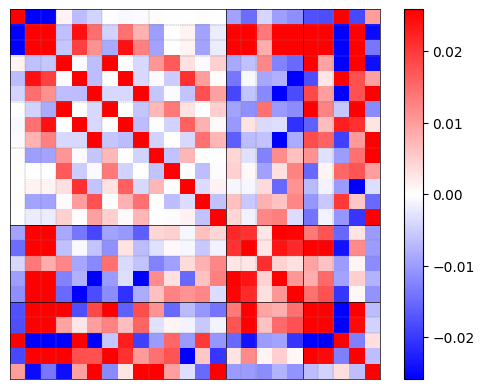

{'max_val': tensor(0.2587),
 'min_val': tensor(3.1371e-05),
 'abs_mean_val': tensor(0.0197),
 'abs_std_val': tensor(0.0318),
 'mean_val': tensor(0.0091),
 'std_val': tensor(0.0363)}

In [23]:
matshow(Target0-Init_H,drawline=[1,1,1,3,3,-5,1,1,-3,1,1,-3])

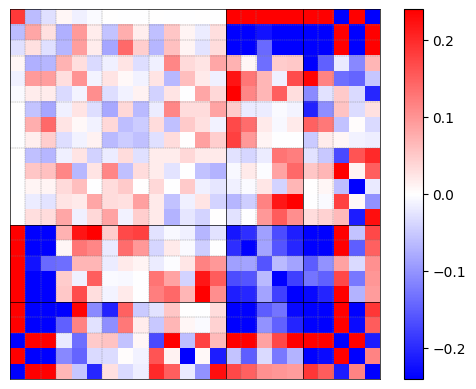

{'max_val': tensor(2.3996),
 'min_val': tensor(0.0001),
 'abs_mean_val': tensor(0.1632),
 'abs_std_val': tensor(0.2757),
 'mean_val': tensor(-0.0064),
 'std_val': tensor(0.3204)}

In [24]:
matshow(Target0-diag_ham_init,drawline=[1,1,1,3,3,-5,1,1,-3,1,1,-3])

{'max_val': tensor(1.4270),
 'min_val': tensor(-2.3996),
 'abs_mean_val': tensor(0.1632),
 'abs_std_val': tensor(0.2757),
 'mean_val': tensor(-0.0064),
 'std_val': tensor(0.3204)}

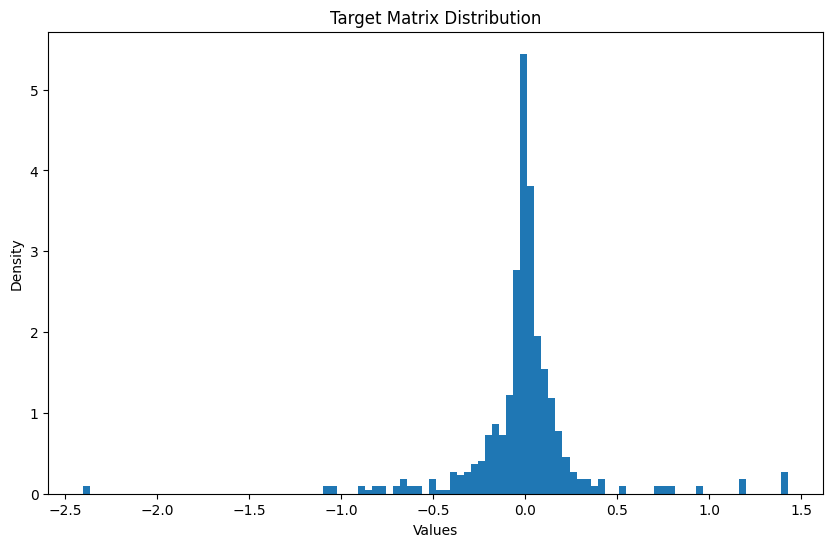

In [25]:
plot_matrix_distribution(Target0-diag_ham_init, "Target Matrix Distribution")

In [26]:
import numpy as np
from scipy.stats import gaussian_kde

def plot_matrix_distribution2(matrices, title="Matrix Distribution", abs_only=False, log_scale=False, colors=None, labels=None):
    """Plot the probability density function of values in multiple matrices.
    
    Args:
        matrices (list[torch.Tensor]): List of input matrices to analyze
        title (str): Title for the plot
        abs_only (bool): Whether to take absolute values
        log_scale (bool): Whether to use log scale for x-axis
        colors (list[str]): List of colors for each matrix distribution
        labels (list[str]): List of labels for each matrix distribution
    
    Returns:
        dict: Statistics of the matrix distributions
    """
    if not isinstance(matrices, list):
        matrices = [matrices]
    
    if colors is None:
        colors = ['b', 'r', 'g', 'c', 'm', 'y', 'k']
    if labels is None:
        labels = [f'Matrix {i+1}' for i in range(len(matrices))]
        
    plt.figure(figsize=(10, 6))
    
    stats = []
    for i, matrix in enumerate(matrices):
        # Flatten the matrix and convert to numpy for plotting
        flat_values = matrix.flatten().detach().numpy()
        if abs_only:
            flat_values = np.abs(flat_values)
            
        # Calculate kernel density estimate
        kernel = gaussian_kde(flat_values)
        x_range = np.linspace(min(flat_values), max(flat_values), 200)
        plt.plot(x_range, kernel(x_range), color=colors[i % len(colors)], label=labels[i])
        
        # Calculate statistics
        stats.append({
            'max_val': matrix.max(),
            'min_val': matrix.min(),
            'abs_mean_val': matrix.abs().mean(),
            'abs_std_val': matrix.abs().std(),
            'mean_val': matrix.mean(),
            'std_val': matrix.std()
        })
    
    plt.title(title)
    plt.xlabel("Values")
    plt.ylabel("Probability Density")
    if log_scale:
        plt.xscale('log')
    plt.legend()
    
    return stats

[{'max_val': tensor(1.4270),
  'min_val': tensor(-2.3996),
  'abs_mean_val': tensor(0.1632),
  'abs_std_val': tensor(0.2757),
  'mean_val': tensor(-0.0064),
  'std_val': tensor(0.3204)},
 {'max_val': tensor(0.2587),
  'min_val': tensor(-0.0898),
  'abs_mean_val': tensor(0.0197),
  'abs_std_val': tensor(0.0318),
  'mean_val': tensor(0.0091),
  'std_val': tensor(0.0363)}]

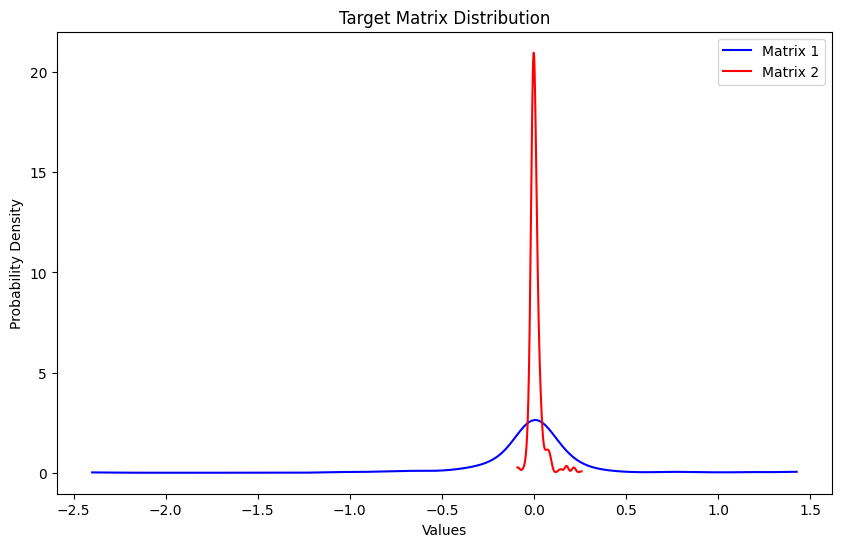

In [27]:
plot_matrix_distribution2([Target0-diag_ham_init,Target0-Init_H], "Target Matrix Distribution")

[{'max_val': tensor(6.9150),
  'min_val': tensor(-18.9063),
  'abs_mean_val': tensor(0.1259),
  'abs_std_val': tensor(0.9570),
  'mean_val': tensor(0.0162),
  'std_val': tensor(0.9652)},
 {'max_val': tensor(6.9428),
  'min_val': tensor(-18.9796),
  'abs_mean_val': tensor(0.2864),
  'abs_std_val': tensor(0.9767),
  'mean_val': tensor(0.0008),
  'std_val': tensor(1.0179)}]

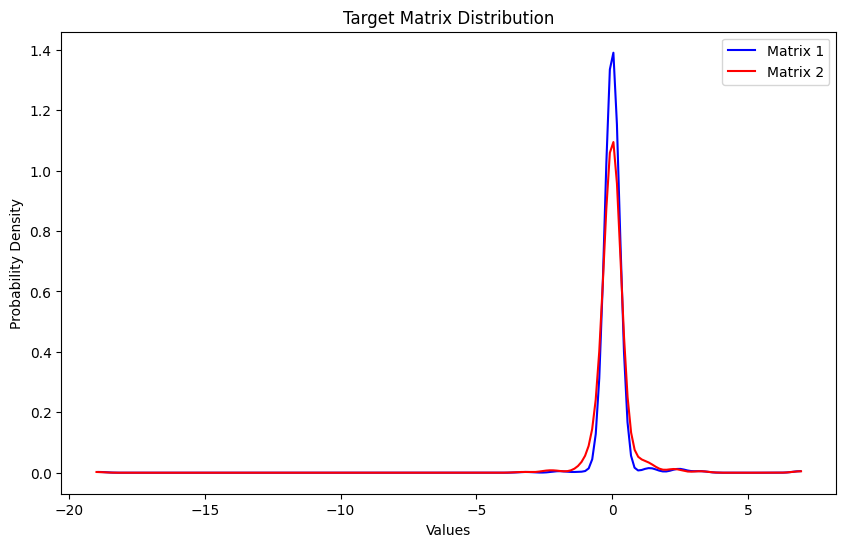

In [28]:
plot_matrix_distribution2([diag_ham_init,Init_H], "Target Matrix Distribution")

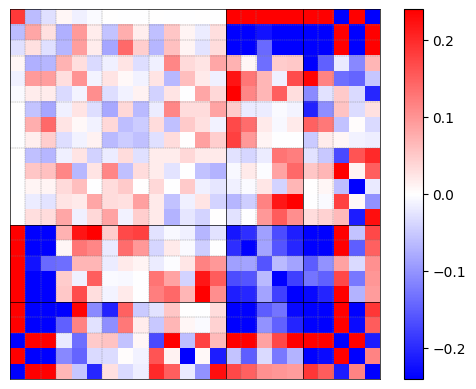

{'max_val': tensor(2.3996),
 'min_val': tensor(0.0001),
 'abs_mean_val': tensor(0.1632),
 'abs_std_val': tensor(0.2757),
 'mean_val': tensor(-0.0064),
 'std_val': tensor(0.3204)}

In [29]:
matshow(Target0-diag_ham_init,drawline=[1,1,1,3,3,-5,1,1,-3,1,1,-3])

In [30]:
ovlp = batch.overlap.squeeze()

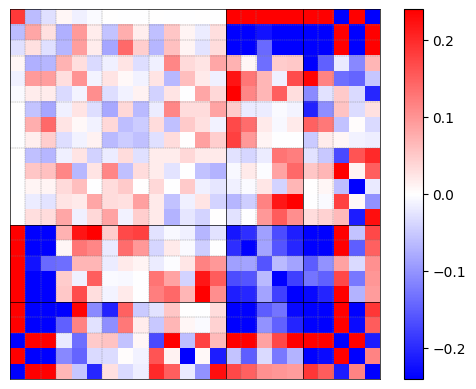

{'max_val': tensor(2.3996),
 'min_val': tensor(0.0001),
 'abs_mean_val': tensor(0.1632),
 'abs_std_val': tensor(0.2757),
 'mean_val': tensor(-0.0064),
 'std_val': tensor(0.3204)}

In [31]:
matshow(Target0 - diag_ham_init,drawline=[1,1,1,3,3,-5,1,1,-3,1,1,-3])

In [32]:
huckel_ovlp = torch.zeros_like(batch.overlap).squeeze()
dim = huckel_ovlp.shape[0]
ovlp = batch.overlap.squeeze()
for i in range(dim):
    for j in range(dim):
        huckel_ovlp[i,j] = ovlp[i,j] * (diag_ham_init[i,i] + diag_ham_init[j,j]) / 2 * 1.75

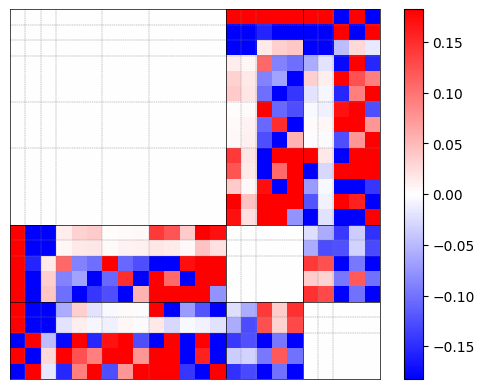

{'max_val': tensor(1.8222),
 'min_val': tensor(0.),
 'abs_mean_val': tensor(0.1468),
 'abs_std_val': tensor(0.2611),
 'mean_val': tensor(-0.0042),
 'std_val': tensor(0.2996)}

In [33]:
matshow(huckel_ovlp * (1-diag_mask),drawline=[1,1,1,3,3,-5,1,1,-3,1,1,-3])

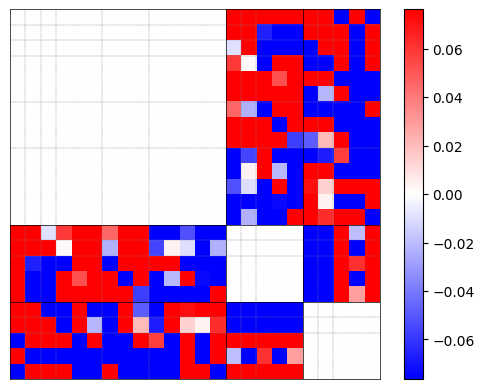

{'max_val': tensor(0.7635),
 'min_val': tensor(0.),
 'abs_mean_val': tensor(0.1246),
 'abs_std_val': tensor(0.1561),
 'mean_val': tensor(0.0036),
 'std_val': tensor(0.1998)}

In [34]:
matshow((Target0 - huckel_ovlp) * (1-diag_mask),drawline=[1,1,1,3,3,-5,1,1,-3,1,1,-3])

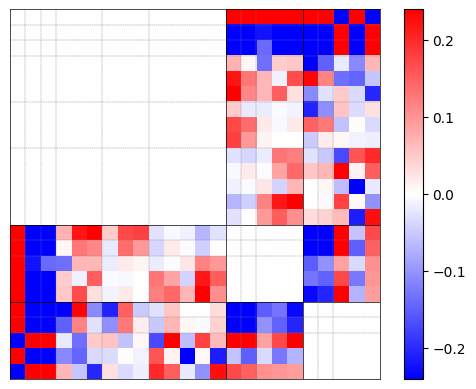

{'max_val': tensor(2.3996),
 'min_val': tensor(0.),
 'abs_mean_val': tensor(0.1291),
 'abs_std_val': tensor(0.2797),
 'mean_val': tensor(-0.0006),
 'std_val': tensor(0.3081)}

In [35]:
matshow((Target0) * (1-diag_mask),drawline=[1,1,1,3,3,-5,1,1,-3,1,1,-3])

[{'max_val': tensor(0.2587),
  'min_val': tensor(-0.0898),
  'abs_mean_val': tensor(0.0197),
  'abs_std_val': tensor(0.0318),
  'mean_val': tensor(0.0091),
  'std_val': tensor(0.0363)},
 {'max_val': tensor(1.4270),
  'min_val': tensor(-2.3996),
  'abs_mean_val': tensor(0.1632),
  'abs_std_val': tensor(0.2757),
  'mean_val': tensor(-0.0064),
  'std_val': tensor(0.3204)},
 {'max_val': tensor(0.7635),
  'min_val': tensor(-0.8475),
  'abs_mean_val': tensor(0.1587),
  'abs_std_val': tensor(0.1499),
  'mean_val': tensor(-0.0021),
  'std_val': tensor(0.2184)}]

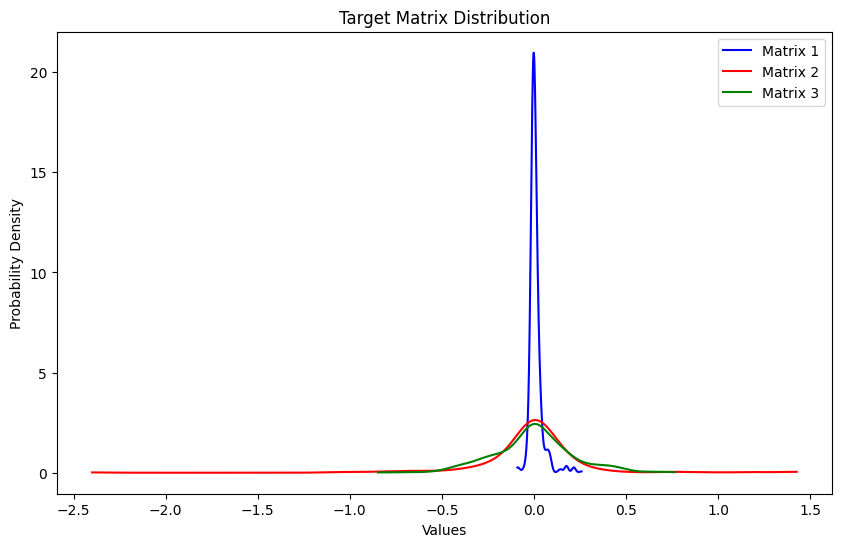

In [37]:
plot_matrix_distribution2([Target0-Init_H, Target0-diag_ham_init, Target0-diag_ham_init-huckel_ovlp*(1-diag_mask)], "Target Matrix Distribution")

In [ ]:
plot_matrix_distribution2(
    [
        (Target0-Init_H)*(1-diag_mask),
        (Target0-diag_ham_init)*(1-diag_mask),
        (Target0-diag_ham_init-huckel_ovlp)*(1-diag_mask),
        ],
    "Target Matrix Distribution")

In [ ]:
plot_matrix_distribution2(
    [
        (Target0-Init_H)*(1-diag_mask),
        (Target0-diag_ham_init)*(1-diag_mask),
        (Target0-diag_ham_init-huckel_ovlp)*(1-diag_mask),
        ],
    "Target Matrix Distribution")